# Used Car Price Prediction — End-to-End Regression Pipeline

**Author:** Mehr
**Objective:** Predict the resale price of used cars using a complete regression pipeline — EDA, preprocessing, multi-model training, cross-validated model selection, final hold-out evaluation, and model persistence.

This notebook follows the same end-to-end methodology applied to the insurance charges regression project, adapted to the `used_cars.csv` dataset.

**Pipeline stages:**
1. Load & Explore
2. Preprocess (cleaning, encoding, scaling, train/test split)
3. Model Training (Linear, Polynomial, Ridge, Lasso)
4. Cross-Validated Model Comparison
5. Final Evaluation on the held-out test set
6. Model Persistence (`joblib`)

> **Key principle:** The test set is isolated immediately after splitting and is never touched until the final evaluation step. All model selection is performed using cross-validation on the training set only.


In [1]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings

warnings.filterwarnings("ignore")

# Scikit-learn
from sklearn.model_selection import train_test_split, cross_val_score, KFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import r2_score, mean_squared_error

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
RANDOM_STATE = 42

np.random.seed(RANDOM_STATE)
print("Libraries loaded successfully.")


Libraries loaded successfully.


## 1. Load & Explore

We start by loading the raw dataset and inspecting its structure, data types, and missing values.

In [2]:
df = pd.read_csv("../data/used_cars.csv")
print(f"Dataset shape: {df.shape[0]} rows x {df.shape[1]} columns")
df.head()


Dataset shape: 52 rows x 27 columns


,id,brand,model,year,miles,city_mileage,highway_mileage,horsepower,torque,engine_capacity_litre,...,type,doors,wheel_drive,engine_type,speed_levels,front_headroom,front_legroom,rear_headroom,rear_legroom,service_records
0,3,Chevrolet,Volt LT,2019,27173,43,42,149,294,1.5,...,sedan,4,2,hybrid_gas_electric,6.0,37.8,42.1,35.8,34.7,4
1,6,Hyundai,Elantra SE,2017,76941,29,38,146,132,2.0,...,sedan,4,2,gas,6.0,39.0,42.2,37.0,35.7,16
2,7,Ford,Focus,2014,97027,27,37,159,146,2.0,...,sedan,4,2,gas,6.0,38.3,43.7,38.0,33.2,13
3,8,Honda,Civic,2016,95396,31,42,158,138,1.5,...,sedan,4,2,gas,6.0,37.5,42.3,36.8,37.4,26
4,9,Hyundai,Elantra SE,2019,28405,29,38,147,132,2.0,...,sedan,4,2,gas,6.0,39.0,42.2,37.0,35.7,5


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 52 entries, 0 to 51
Data columns (total 27 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     52 non-null     int64  
 1   brand                  52 non-null     str    
 2   model                  52 non-null     str    
 3   year                   52 non-null     int64  
 4   miles                  52 non-null     int64  
 5   city_mileage           52 non-null     int64  
 6   highway_mileage        52 non-null     int64  
 7   horsepower             52 non-null     int64  
 8   torque                 52 non-null     int64  
 9   engine_capacity_litre  52 non-null     float64
 10  fuel_capacity          52 non-null     float64
 11  num_cylinder           52 non-null     int64  
 12  num_seat               52 non-null     int64  
 13  num_owners             52 non-null     int64  
 14  price                  52 non-null     int64  
 15  link               

In [4]:
df.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,52.0,NaN,NaN,NaN,31.365385,15.378912,3.0,18.75,31.5,44.25,57.0
brand,52,6,Honda,23,NaN,NaN,NaN,NaN,NaN,NaN,NaN
model,52,15,Civic,14,NaN,NaN,NaN,NaN,NaN,NaN,NaN
year,52.0,NaN,NaN,NaN,2018.673077,1.39637,2014.0,2018.0,2019.0,2019.25,2022.0
miles,52.0,NaN,NaN,NaN,33901.25,22700.646139,5000.0,16454.75,27448.5,42442.0,97027.0
city_mileage,52.0,NaN,NaN,NaN,29.038462,5.947356,17.0,26.5,30.0,30.0,55.0
highway_mileage,52.0,NaN,NaN,NaN,37.423077,4.136619,24.0,35.75,38.0,40.0,49.0
horsepower,52.0,NaN,NaN,NaN,176.865385,33.793507,143.0,152.0,159.5,192.0,288.0
torque,52.0,NaN,NaN,NaN,177.923077,47.256433,99.0,138.0,181.0,192.0,294.0
engine_capacity_litre,52.0,NaN,NaN,NaN,1.832692,0.379743,1.4,1.5,2.0,2.0,3.5


In [5]:
# Missing value audit
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_summary = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
missing_summary[missing_summary["missing_count"] > 0].sort_values("missing_pct", ascending=False)


,missing_count,missing_pct
condition,51,98.08
speed_levels,1,1.92


**Observations:**
- `condition` is missing in 51 of 52 rows (~98%) — effectively no signal, so it will be **dropped**.
- `speed_levels` has a single missing value — it will be **imputed** with the column median.
- `id` and `link` are identifier/URL columns with no predictive value — both will be **dropped**.
- `type` contains a single constant value (`sedan`) across all rows — zero variance, **dropped**.


## 2. Visualize Distributions

We examine the distribution of the target variable (`price`) and key numeric features to understand scale, skewness, and outliers.

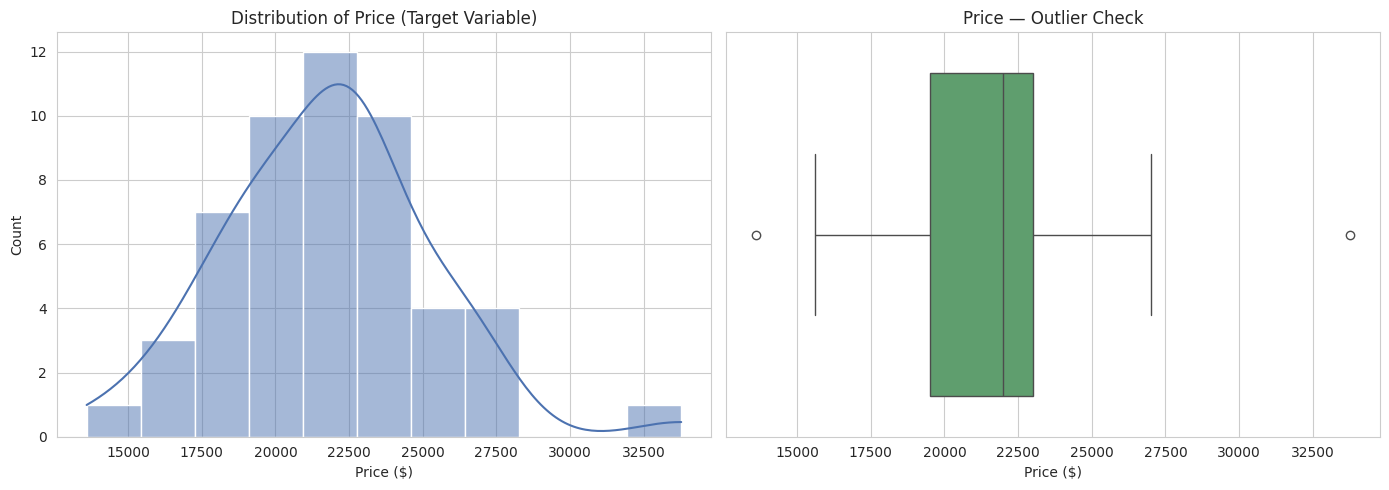

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df["price"], kde=True, ax=axes[0], color="#4C72B0")
axes[0].set_title("Distribution of Price (Target Variable)")
axes[0].set_xlabel("Price ($)")

sns.boxplot(x=df["price"], ax=axes[1], color="#55A868")
axes[1].set_title("Price — Outlier Check")
axes[1].set_xlabel("Price ($)")

plt.tight_layout()
plt.savefig("../images/price_distribution.png", dpi=120, bbox_inches="tight")
plt.show()


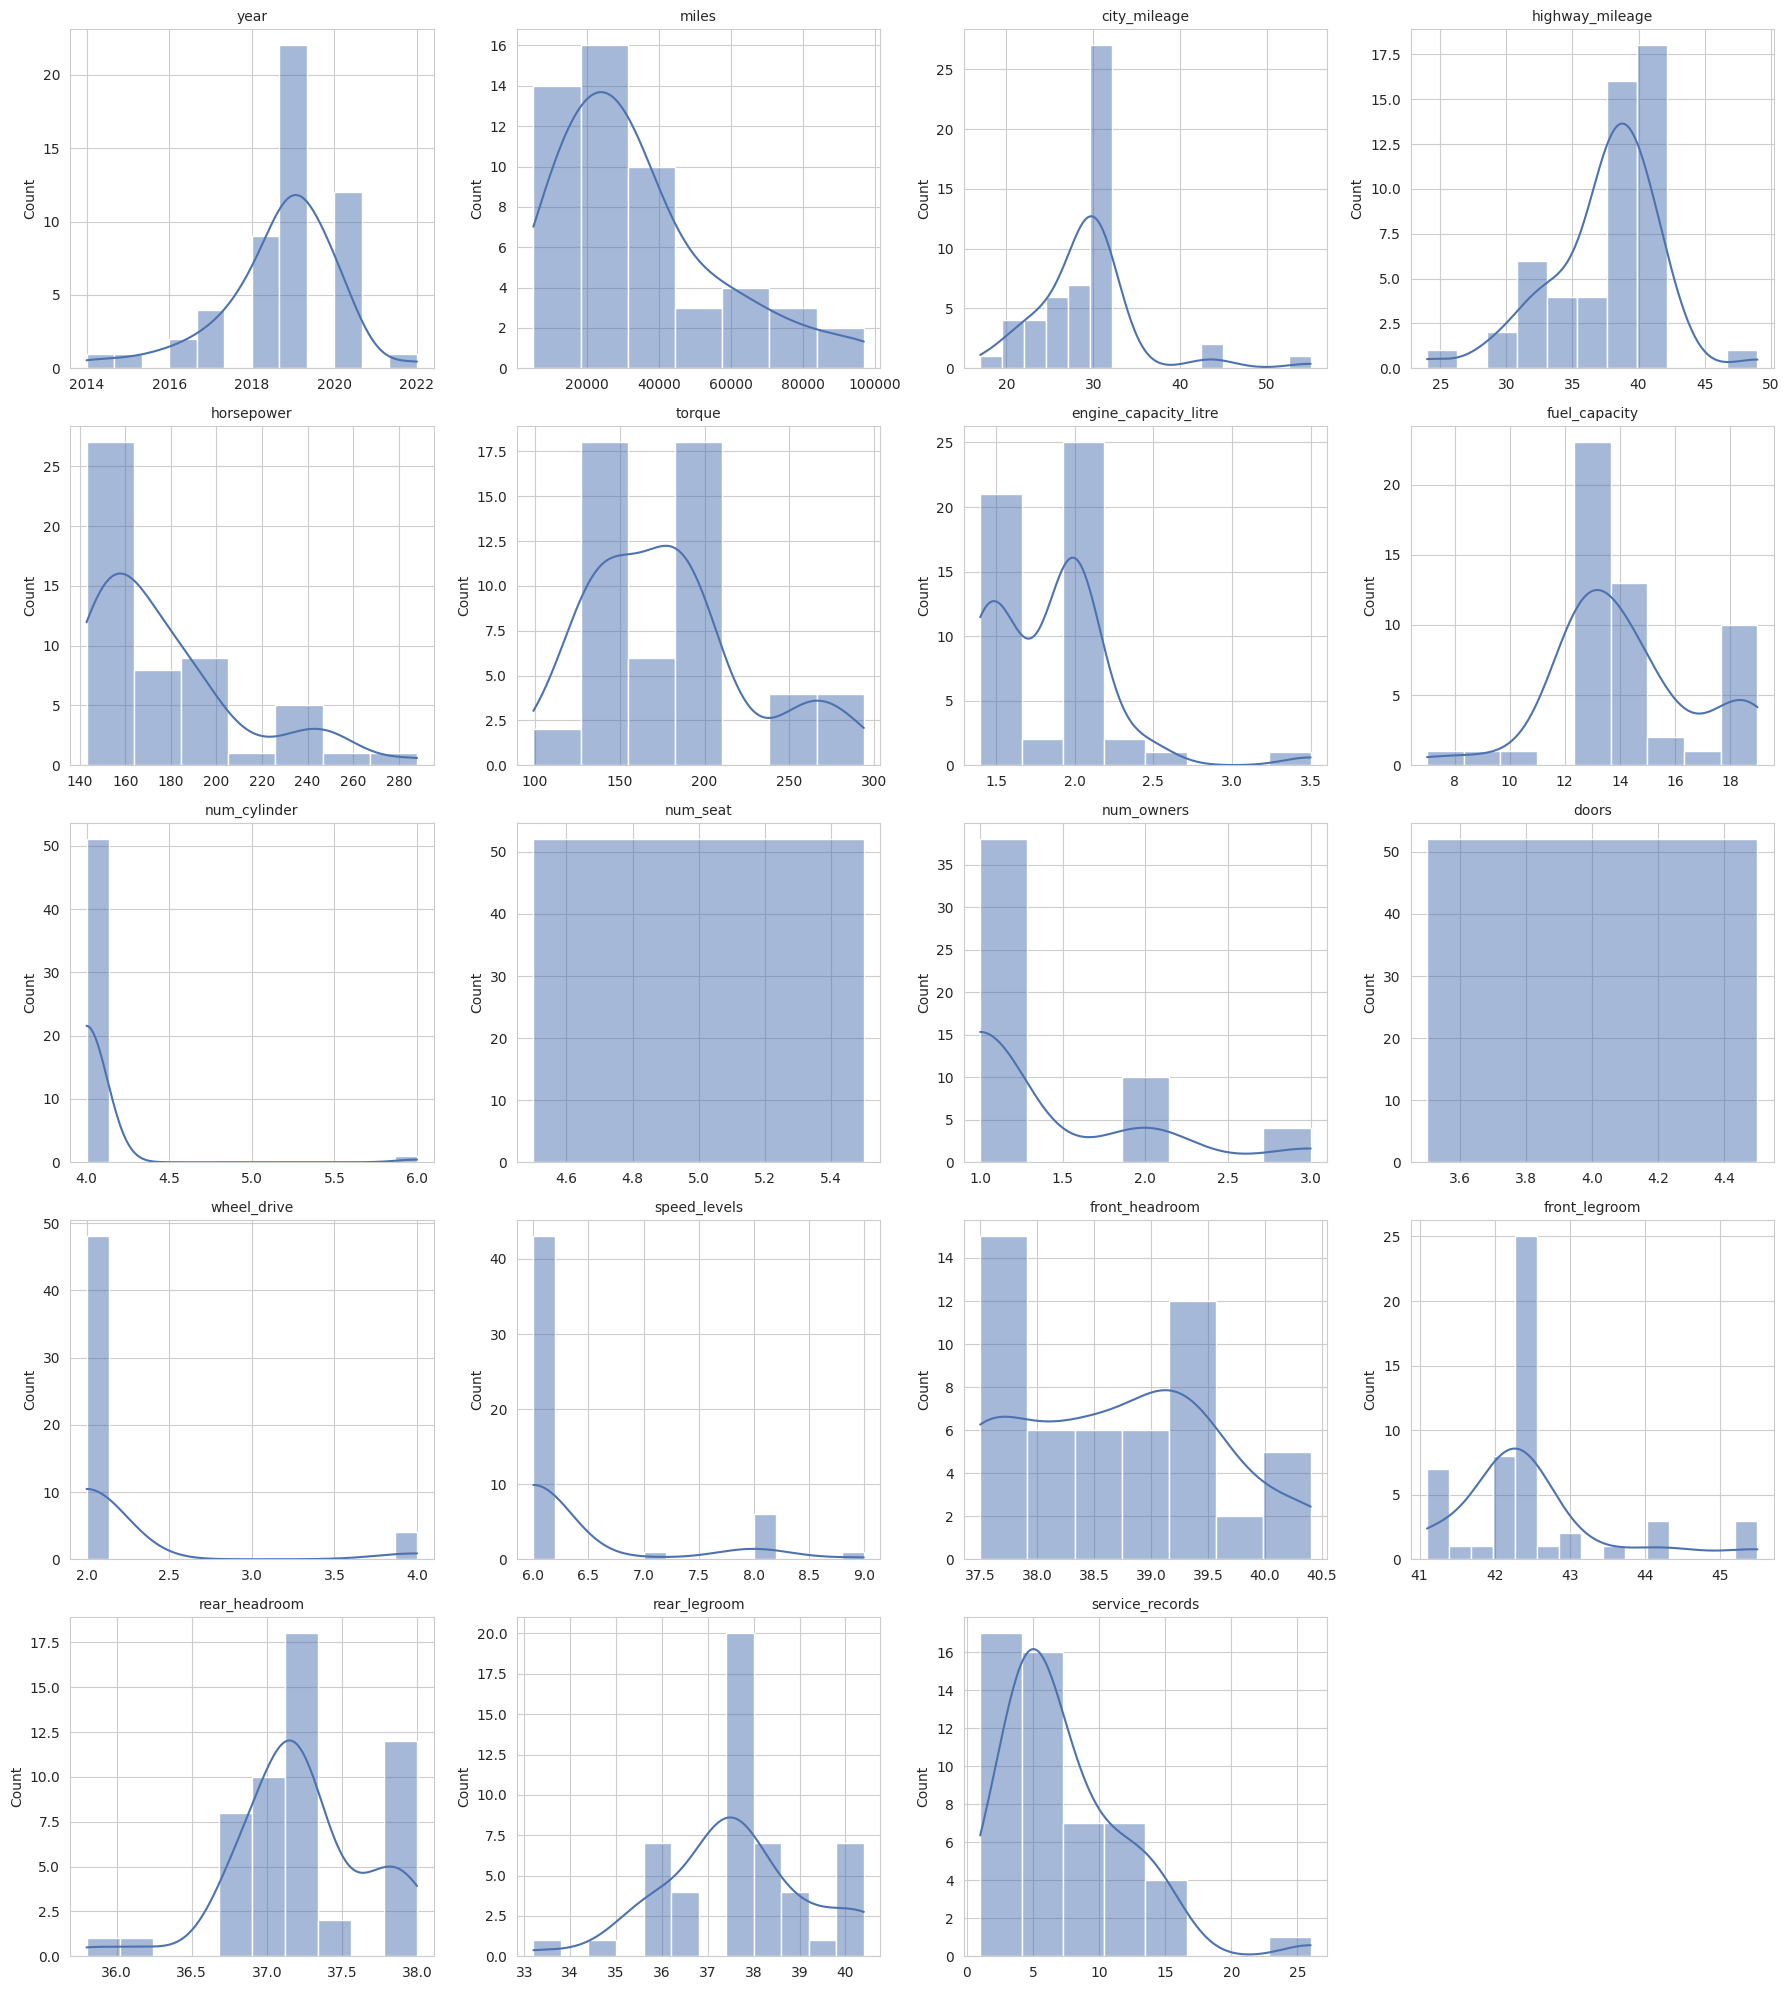

In [7]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c not in ["id", "price", "condition"]]

n_cols = 4
n_rows = int(np.ceil(len(numeric_cols) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(df[col].dropna(), kde=True, ax=axes[i], color="#4C72B0")
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel("")

for j in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig("../images/numeric_distributions.png", dpi=120, bbox_inches="tight")
plt.show()


## 3. Correlation & Relationships

We compute the correlation matrix for numeric features and visualize the relationship between the strongest predictors and `price`.

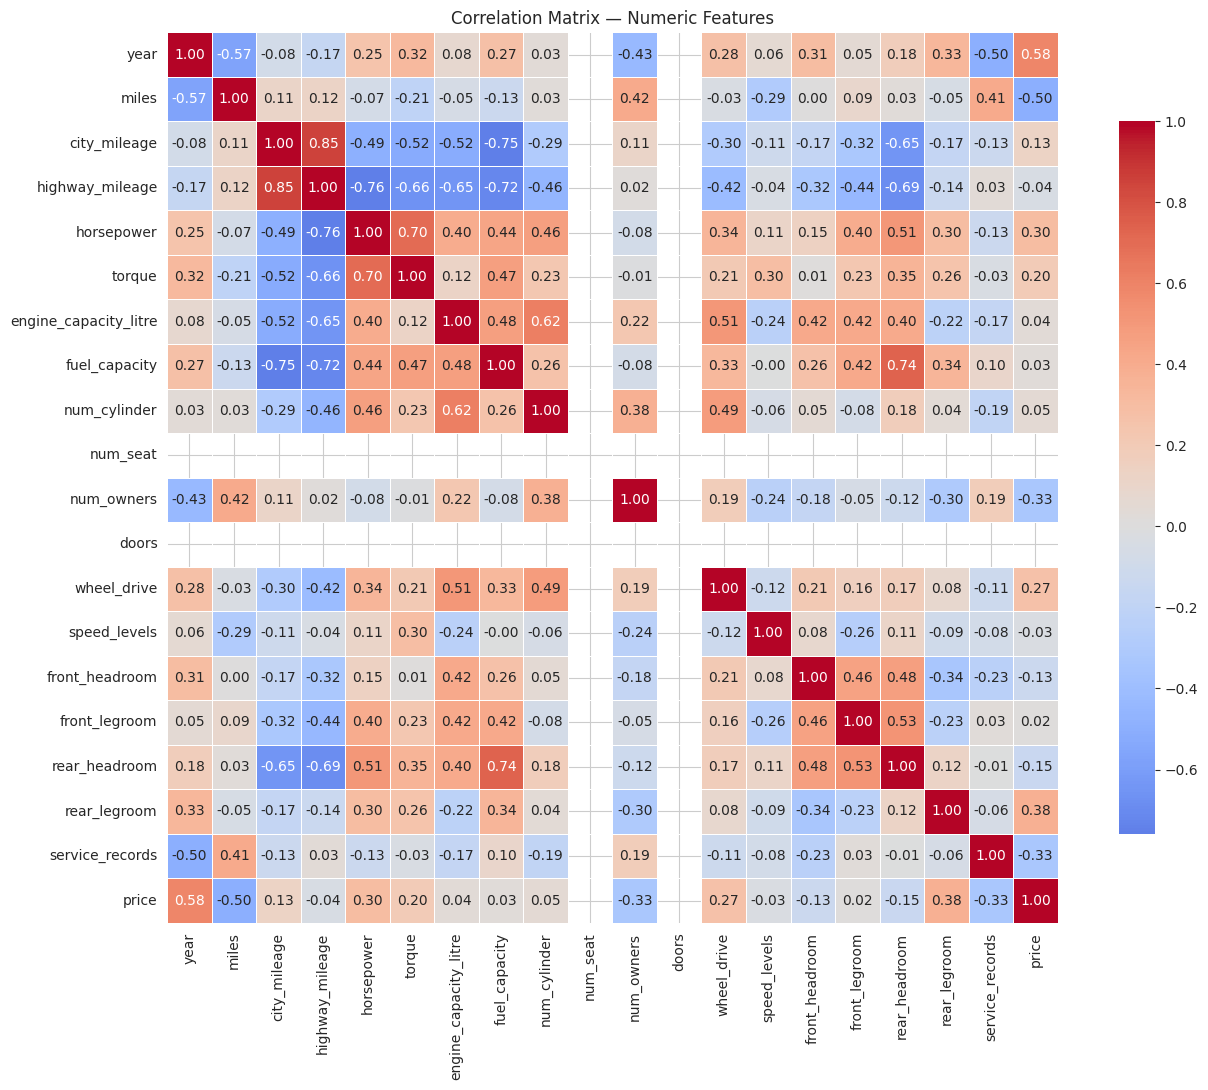

In [8]:
corr_cols = numeric_cols + ["price"]
corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(14, 11))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title("Correlation Matrix — Numeric Features")
plt.tight_layout()
plt.savefig("../images/correlation_heatmap.png", dpi=120, bbox_inches="tight")
plt.show()


In [9]:
price_corr = corr_matrix["price"].drop("price").sort_values(key=abs, ascending=False)
print("Top features correlated with price:\n")
print(price_corr)


Top features correlated with price:

year                     0.581254
miles                   -0.500769
rear_legroom             0.377287
num_owners              -0.327853
service_records         -0.327306
horsepower               0.301800
wheel_drive              0.268273
torque                   0.199764
rear_headroom           -0.145403
city_mileage             0.131767
front_headroom          -0.129595
num_cylinder             0.049216
highway_mileage         -0.041956
engine_capacity_litre    0.038197
fuel_capacity            0.027480
speed_levels            -0.026826
front_legroom            0.015819
num_seat                      NaN
doors                         NaN
Name: price, dtype: float64


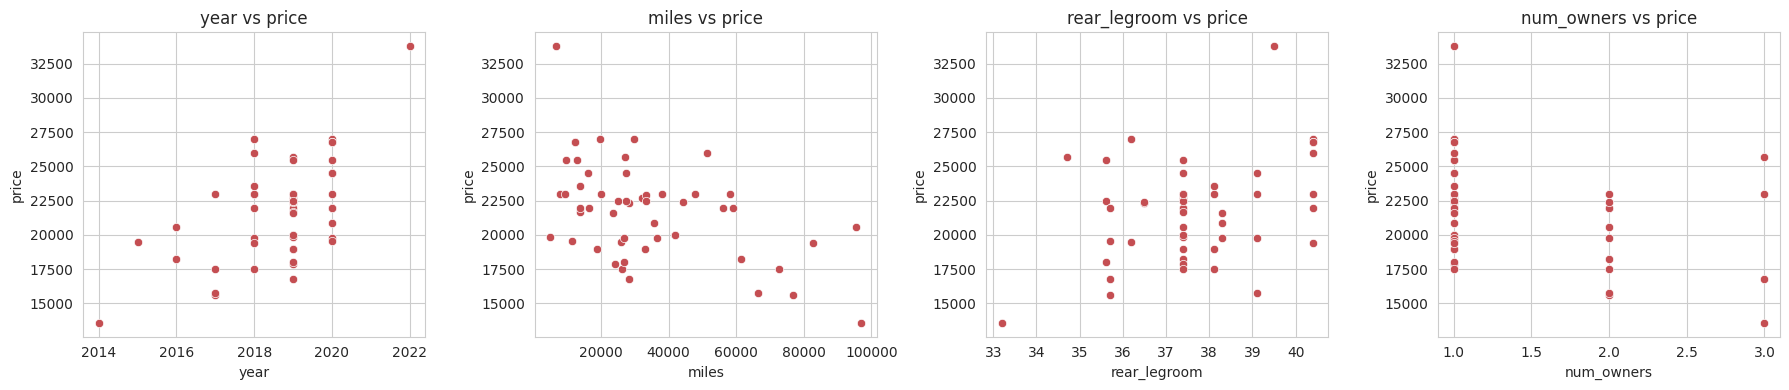

In [10]:
top_features = price_corr.abs().sort_values(ascending=False).head(4).index.tolist()

fig, axes = plt.subplots(1, len(top_features), figsize=(18, 4))
for i, feat in enumerate(top_features):
    sns.scatterplot(x=df[feat], y=df["price"], ax=axes[i], color="#C44E52")
    axes[i].set_title(f"{feat} vs price")

plt.tight_layout()
plt.savefig("../images/top_feature_relationships.png", dpi=120, bbox_inches="tight")
plt.show()


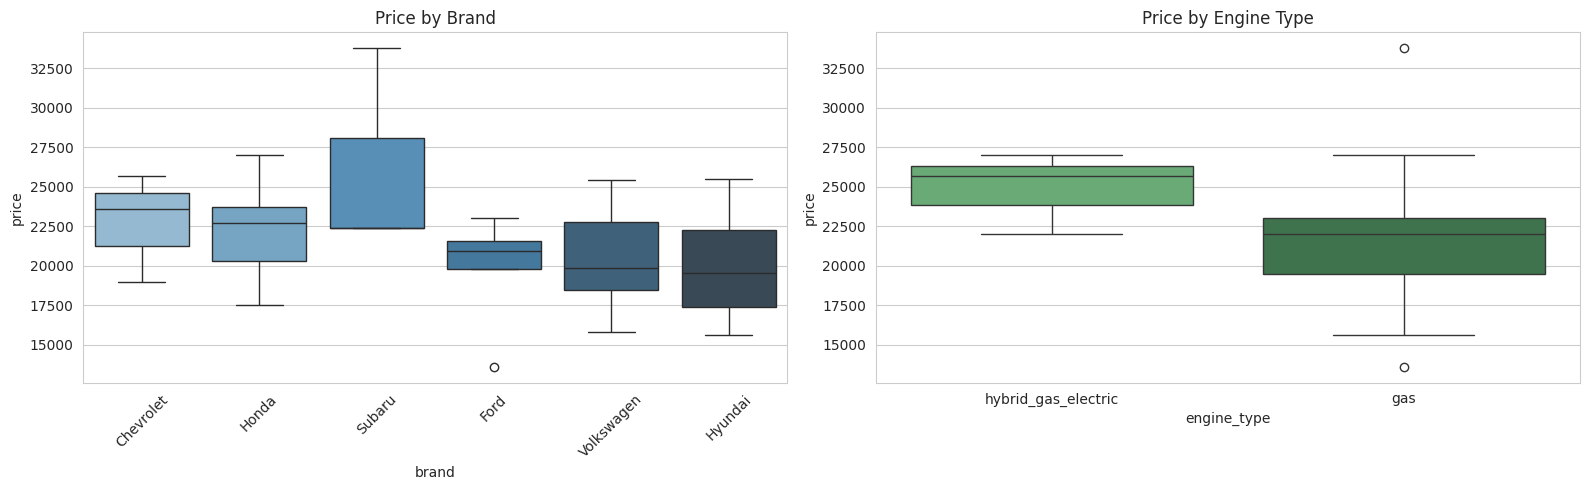

In [11]:
# Categorical feature impact on price
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

brand_order = df.groupby("brand")["price"].median().sort_values(ascending=False).index
sns.boxplot(data=df, x="brand", y="price", order=brand_order, ax=axes[0], palette="Blues_d")
axes[0].set_title("Price by Brand")
axes[0].tick_params(axis="x", rotation=45)

sns.boxplot(data=df, x="engine_type", y="price", ax=axes[1], palette="Greens_d")
axes[1].set_title("Price by Engine Type")

plt.tight_layout()
plt.savefig("../images/categorical_price_impact.png", dpi=120, bbox_inches="tight")
plt.show()


## 4. Data Cleaning & Preprocessing

Steps performed:
1. Drop non-predictive columns: `id`, `link`, `condition` (98% missing), `type` (zero variance).
2. Separate features (`X`) and target (`y` = `price`).
3. Identify numeric vs. categorical columns for the preprocessing pipeline.
4. Build a `ColumnTransformer` that:
   - Imputes missing numeric values with the **median**.
   - Scales numeric features with `StandardScaler`.
   - One-hot encodes categorical features (`brand`, `model`, `engine_type`).
5. Split into **80% train / 20% test**, with the test set held out until final evaluation.


In [12]:
drop_cols = ["id", "link", "condition", "type"]
df_model = df.drop(columns=drop_cols)

X = df_model.drop(columns=["price"])
y = df_model["price"]

categorical_features = X.select_dtypes(include=["object", "string"]).columns.tolist()
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()

print("Numeric features:", numeric_features)
print("\nCategorical features:", categorical_features)


Numeric features: ['year', 'miles', 'city_mileage', 'highway_mileage', 'horsepower', 'torque', 'engine_capacity_litre', 'fuel_capacity', 'num_cylinder', 'num_seat', 'num_owners', 'doors', 'wheel_drive', 'speed_levels', 'front_headroom', 'front_legroom', 'rear_headroom', 'rear_legroom', 'service_records']

Categorical features: ['brand', 'model', 'engine_type']


In [13]:
from sklearn.impute import SimpleImputer

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features),
])

print("Preprocessor configured.")


Preprocessor configured.


In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE
)

print(f"Training set: {X_train.shape[0]} rows")
print(f"Test set:     {X_test.shape[0]} rows  (held out — not touched until final evaluation)")


Training set: 41 rows
Test set:     11 rows  (held out — not touched until final evaluation)


## 5. Model Training & Cross-Validation

We train four candidate models, all wrapped in a `Pipeline` with the same preprocessing step to prevent data leakage:

1. **Linear Regression** — baseline.
2. **Polynomial Regression** (degree 2) — captures non-linear relationships.
3. **Ridge Regression** — L2-regularized, tuned over a range of `alpha`.
4. **Lasso Regression** — L1-regularized (feature selection), tuned over a range of `alpha`.

Hyperparameters for Ridge and Lasso are tuned via `GridSearchCV` using 5-fold cross-validation on the **training set only**, scored on R².


In [15]:
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

results = {}
fitted_models = {}


In [16]:
# 1. Baseline Linear Regression
lin_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LinearRegression()),
])

lin_scores = cross_val_score(lin_pipe, X_train, y_train, cv=cv, scoring="r2")
results["Linear Regression"] = lin_scores
lin_pipe.fit(X_train, y_train)
fitted_models["Linear Regression"] = lin_pipe

print(f"Linear Regression CV R^2 scores: {np.round(lin_scores, 3)}")
print(f"Mean R^2: {lin_scores.mean():.4f}  (+/- {lin_scores.std():.4f})")


Linear Regression CV R^2 scores: [-5.56640000e+01 -2.26690000e+01 -6.04243477e+06 -4.43708000e+02
 -1.29720000e+01]
Mean R^2: -1208593.9569  (+/- 2416920.4126)


In [17]:
# 2. Polynomial Regression (degree 2)
poly_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("model", LinearRegression()),
])

poly_scores = cross_val_score(poly_pipe, X_train, y_train, cv=cv, scoring="r2")
results["Polynomial Regression (deg=2)"] = poly_scores
poly_pipe.fit(X_train, y_train)
fitted_models["Polynomial Regression (deg=2)"] = poly_pipe

print(f"Polynomial Regression CV R^2 scores: {np.round(poly_scores, 3)}")
print(f"Mean R^2: {poly_scores.mean():.4f}  (+/- {poly_scores.std():.4f})")


Polynomial Regression CV R^2 scores: [ -4.985   0.402  -0.623  -0.146 -10.25 ]


Mean R^2: -3.1204  (+/- 4.0447)


In [18]:
# 3. Ridge Regression — hyperparameter tuning via GridSearchCV
ridge_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", Ridge(random_state=RANDOM_STATE)),
])

ridge_param_grid = {"model__alpha": [0.01, 0.1, 1.0, 5.0, 10.0, 50.0, 100.0]}

ridge_grid = GridSearchCV(ridge_pipe, ridge_param_grid, cv=cv, scoring="r2", n_jobs=-1)
ridge_grid.fit(X_train, y_train)

best_ridge = ridge_grid.best_estimator_
ridge_scores = cross_val_score(best_ridge, X_train, y_train, cv=cv, scoring="r2")
results["Ridge Regression"] = ridge_scores
fitted_models["Ridge Regression"] = best_ridge

print(f"Best alpha: {ridge_grid.best_params_['model__alpha']}")
print(f"Ridge CV R^2 scores: {np.round(ridge_scores, 3)}")
print(f"Mean R^2: {ridge_scores.mean():.4f}  (+/- {ridge_scores.std():.4f})")


Best alpha: 10.0
Ridge CV R^2 scores: [0.257 0.647 0.642 0.202 0.514]
Mean R^2: 0.4524  (+/- 0.1888)


In [19]:
# 4. Lasso Regression — hyperparameter tuning via GridSearchCV
lasso_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", Lasso(random_state=RANDOM_STATE, max_iter=20000)),
])

lasso_param_grid = {"model__alpha": [0.01, 0.1, 1.0, 5.0, 10.0, 50.0, 100.0]}

lasso_grid = GridSearchCV(lasso_pipe, lasso_param_grid, cv=cv, scoring="r2", n_jobs=-1)
lasso_grid.fit(X_train, y_train)

best_lasso = lasso_grid.best_estimator_
lasso_scores = cross_val_score(best_lasso, X_train, y_train, cv=cv, scoring="r2")
results["Lasso Regression"] = lasso_scores
fitted_models["Lasso Regression"] = best_lasso

print(f"Best alpha: {lasso_grid.best_params_['model__alpha']}")
print(f"Lasso CV R^2 scores: {np.round(lasso_scores, 3)}")
print(f"Mean R^2: {lasso_scores.mean():.4f}  (+/- {lasso_scores.std():.4f})")


Best alpha: 10.0
Lasso CV R^2 scores: [0.306 0.587 0.651 0.104 0.074]
Mean R^2: 0.3444  (+/- 0.2389)


## 6. Model Comparison

We summarize the cross-validated R² performance of all four candidates in a table and a bar chart, then select the model with the highest mean CV R².

In [20]:
summary_df = pd.DataFrame({
    "Model": list(results.keys()),
    "Mean CV R2": [scores.mean() for scores in results.values()],
    "Std CV R2": [scores.std() for scores in results.values()],
    "Min CV R2": [scores.min() for scores in results.values()],
    "Max CV R2": [scores.max() for scores in results.values()],
}).sort_values("Mean CV R2", ascending=False).reset_index(drop=True)

summary_df


,Model,Mean CV R2,Std CV R2,Min CV R2,Max CV R2
0,Ridge Regression,4.524098e-01,1.888300e-01,2.017657e-01,0.646564
1,Lasso Regression,3.443582e-01,2.388567e-01,7.361064e-02,0.651187
2,Polynomial Regression (deg=2),-3.120437e+00,4.044692e+00,-1.024989e+01,0.401787
3,Linear Regression,-1.208594e+06,2.416920e+06,-6.042435e+06,-12.972119


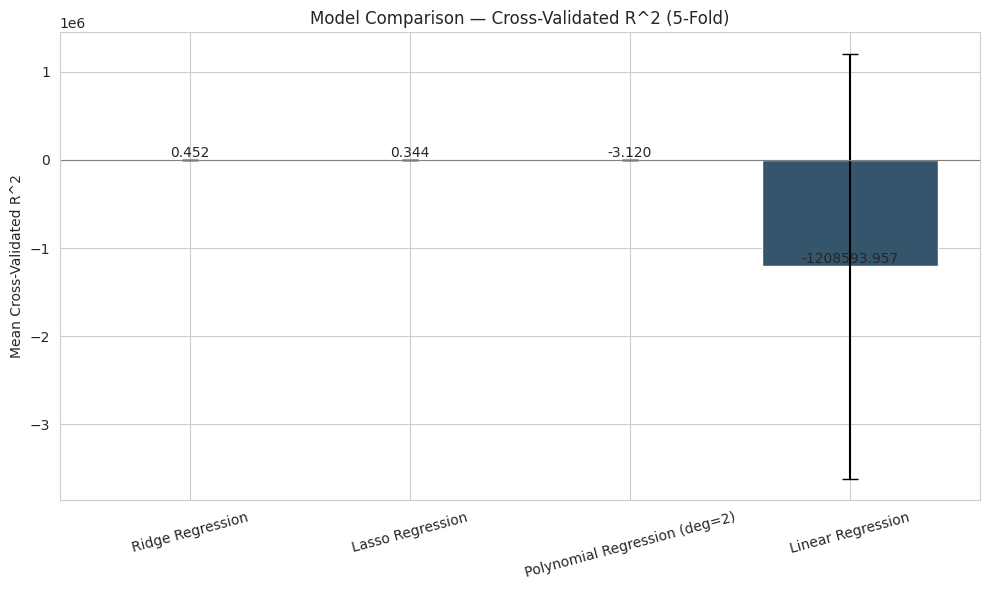

In [21]:
plt.figure(figsize=(10, 6))
bars = plt.bar(summary_df["Model"], summary_df["Mean CV R2"],
                yerr=summary_df["Std CV R2"], capsize=6,
                color=sns.color_palette("Blues_d", len(summary_df)))
plt.ylabel("Mean Cross-Validated R^2")
plt.title("Model Comparison — Cross-Validated R^2 (5-Fold)")
plt.xticks(rotation=15)
plt.axhline(0, color="grey", linewidth=0.8)

for bar, val in zip(bars, summary_df["Mean CV R2"]):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
              f"{val:.3f}", ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.savefig("../images/model_comparison.png", dpi=120, bbox_inches="tight")
plt.show()


In [22]:
best_model_name = summary_df.iloc[0]["Model"]
best_model = fitted_models[best_model_name]

print(f"Selected model (highest mean CV R^2): {best_model_name}")
print(f"Mean CV R^2: {summary_df.iloc[0]['Mean CV R2']:.4f}")


Selected model (highest mean CV R^2): Ridge Regression
Mean CV R^2: 0.4524


## 7. Final Evaluation on the Held-Out Test Set

The winning model is now evaluated **once** on the untouched 20% test set to obtain an unbiased estimate of generalization performance.

In [23]:
y_pred = best_model.predict(X_test)

test_r2 = r2_score(y_test, y_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
test_mae = np.mean(np.abs(y_test - y_pred))

print(f"Final Model: {best_model_name}")
print(f"Test R^2:    {test_r2:.4f}")
print(f"Test RMSE:   ${test_rmse:,.2f}")
print(f"Test MAE:    ${test_mae:,.2f}")


Final Model: Ridge Regression
Test R^2:    0.3479
Test RMSE:   $1,986.41
Test MAE:    $1,590.68


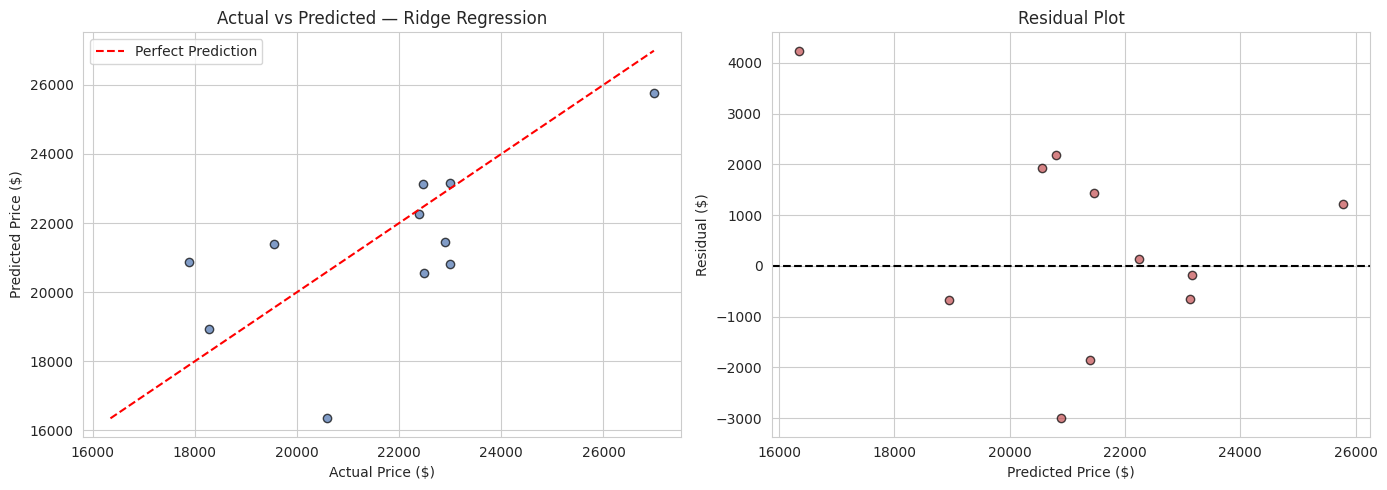

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test, y_pred, alpha=0.7, color="#4C72B0", edgecolor="k")
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
axes[0].plot(lims, lims, "r--", linewidth=1.5, label="Perfect Prediction")
axes[0].set_xlabel("Actual Price ($)")
axes[0].set_ylabel("Predicted Price ($)")
axes[0].set_title(f"Actual vs Predicted — {best_model_name}")
axes[0].legend()

residuals = y_test - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.7, color="#C44E52", edgecolor="k")
axes[1].axhline(0, color="black", linestyle="--", linewidth=1.5)
axes[1].set_xlabel("Predicted Price ($)")
axes[1].set_ylabel("Residual ($)")
axes[1].set_title("Residual Plot")

plt.tight_layout()
plt.savefig("../images/final_model_evaluation.png", dpi=120, bbox_inches="tight")
plt.show()


## 8. Persist the Final Model

The final, fitted pipeline (preprocessing + best model) is saved with `joblib` so it can be reloaded for inference without retraining.

In [25]:
import joblib

joblib.dump(best_model, "../models/used_cars_model.pkl")
print("Model saved to ../models/used_cars_model.pkl")


Model saved to ../models/used_cars_model.pkl


In [26]:
# Sanity check: reload and verify predictions match
reloaded_model = joblib.load("../models/used_cars_model.pkl")
reloaded_preds = reloaded_model.predict(X_test)

assert np.allclose(reloaded_preds, y_pred), "Mismatch between original and reloaded model predictions!"
print("Reloaded model produces identical predictions. Model persistence verified.")


Reloaded model produces identical predictions. Model persistence verified.


## 9. Summary

| Stage | Outcome |
|---|---|
| Dataset | `used_cars.csv` — 52 records, 27 raw columns |
| Dropped columns | `id`, `link`, `condition` (98% missing), `type` (zero variance) |
| Preprocessing | Median imputation + `StandardScaler` (numeric); most-frequent imputation + `OneHotEncoder` (categorical) |
| Train/Test split | 80% / 20%, test set untouched until final evaluation |
| Candidates | Linear, Polynomial (deg=2), Ridge (tuned), Lasso (tuned) |
| Model selection | Highest mean 5-fold cross-validated R² on training data |
| **Selected model** | **See Section 6 output above** |
| Final test performance | See R² and RMSE printed in Section 7 |
| Persisted artifact | `models/used_cars_model.pkl` |

This notebook satisfies all assignment requirements: EDA, preprocessing, multi-model training with cross-validation, model comparison, final hold-out evaluation, and model persistence via `joblib`.
